# Submission 1: Your Model, Your Beam
### ME 323 Module 1

<img src="https://raw.githubusercontent.com/andrewvoss8-boop/core-me-data-science-activities-public/main/me323/Module1_drafts/figures/I_beam_dimensions.jpg" alt="I-beam dimensions" width="220">

Both common class designs have been queried. The scoreboard so far:

| design | (b, H_web) | predicted | returned strength and str/w on estimated-mass basis |
|---|---|---|---|
| equation-query beam from Pre-lab 1 | (1.10, 13.25) | 48.7 N/g | **37.48 N/g** (475.7 N) |
| locked GP-query beam from Pre-lab 2, MUI ψ=1 | (1.00, 13.39) | 36.7 N/g | **36.65 N/g** (445.8 N) |

The equation beam beat the 15-beam handout best of 36.88 N/g and is the best
of all 17. The GP beam probed the b = 1.0 edge of the newly opened box and
came back at 36.65 N/g — below the handout best, and close to what the model
expected there. Relative to their own predictions, the equation result came
in 23.0% low and the GP result just 0.0% below its 36.7 N/g prediction. Sit
with that pair of facts: the winning beam came from the prediction that
missed by 23.0%, while the nearly calibrated prediction described a beam not
worth building. A model can be honest about a mediocre region and still lose
to an overconfident one that happened to point somewhere better. One test
settles less than it seems to.

Both returned strengths came from the staff ground truth model — fit to the
prior test campaign, standing in for the testing machine — so nothing has
been printed yet. That changes here: fold both query results into the data,
build a model your way, and commit to a third design, the beam your group will
actually print and break. Do not call either common query beam your
Submission 1 design unless you deliberately choose those coordinates. The
final answer is a decision defended in the memo.

## Your knobs

This notebook hands you a working pipeline, but every modeling decision in it
is a variable you set: an assumption that goes into the model, not a setting
with a known right answer. The full dashboard:

| knob | variable (where) | options | the assumption you are making |
|---|---|---|---|
| model architecture | `CHOICE` (section 3) | `"A plain"` / `"B strength"` / `"C features"` / `"D residual"` | how much physics the model gets, and what quantity it learns — section 2 |
| prediction target | comes with the lane | str/w directly (lanes A, C, D) or raw strength ÷ mass (lane B) | which quantity is the smoother, easier thing to learn — section 2 |
| kernel | `KERNEL` (section 3) | `"RBF"` / `"Matern"` | how smooth the true strength surface is — section 3 |
| assumed noise | `NOISE_PCT` (section 3) | any percent; class default 3, pooled campaign repeats ≈ 4.4 (Pre-lab 2 section 4) | how much of beam-to-beam scatter is repeatability rather than real shape — section 3 |
| acquisition rule | `ACQ` (section 4) | `"MUI"` / `"EI"` | how predicted value and uncertainty combine into one pick — section 4 |
| explore vs exploit | `psi` (section 4, MUI only) | 0 = pure exploit; larger = more explore | how much a *chance* at a better beam is worth against a safe, good one — section 4 |

Two kinds of knobs, two ways to choose. Architecture and kernel make claims
the data can score, and the leave-one-out table in section 2 is their referee. Noise
and ψ make claims the data *cannot* score: no table can tell you the rig's
repeatability or how much risk your group should carry. Those you defend in
the memo with physical reasoning and stated values.

One more thing, since this module keeps saying there is no right answer: that
is a claim about the knobs, not about the grade. The grade follows the
defense, not the distance from the defaults — a defended default recipe
outscores an arbitrary exotic one.

**Which of these are really yours?** Not all six knobs carry the same weight.
Two are load-bearing decisions your group owns: the **lane** (how physics and
data combine — the module's central modeling question) and the **risk
posture** (`ACQ` plus its dial — how aggressively you chase predicted
performance versus uncertainty). The others — kernel, noise, target scale —
are assumptions you **stress-test**: after you commit to coordinates, check
whether they survive the kernel swap and the 1/3/10% noise refits, and report
what you find. "Our exact optimum moves under reasonable assumptions, but
every defensible model points at this neighborhood, so we chose a printable
point inside the stable region" is a stronger engineering conclusion than any
single recipe. And if your pick does *not* survive — say so: an unstable
recommendation is exactly when buying information beats chasing the current
maximum, and a memo that argues that earns its credit.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

# Fixed geometry (you choose b and H_web; everything else is set)
B, TH, L = 10.0, 18.0, 150.0     # flange width, total height, test span (mm)
LP = 172.0                        # printed length (mm); overhangs the 150 mm span
KMASS = 0.2045                    # g/mm^2: mass per unit cross-section area at 172 mm

# Handbook starting values — Pre-lab 1 calibrates the three marked ones
SY = 76e6                         # Pa, PLA strength                 (calibrated)
K_LTB = 0.33                      # fixture effective-length factor  (calibrated)
TAU_I = 43.9e6                    # printed-interface shear strength (Pa) — starting
                                  # guess = bulk yield / sqrt(3)     (calibrated)
E, G = 2.5e9, 2.5e9 / 2.6         # Young's / shear modulus (Pa) — fixed
C1, C2 = 1.35, 0.55               # LTB moment-gradient / load-height factors
URL = ("https://raw.githubusercontent.com/andrewvoss8-boop/"
       "core-me-data-science-activities-public/main/data/student_beams_B10_L150.csv")
try:
    df = pd.read_csv(URL); print("loaded from GitHub")
except Exception:
    try:
        df = pd.read_csv("student_beams_B10_L150.csv"); print("loaded local copy")
    except FileNotFoundError as e:
        raise FileNotFoundError(
            "no internet and no local copy -- download student_beams_B10_L150.csv "
            "from the course page into this notebook's folder and rerun") from e
df = df.rename(columns={"b_mm": "b", "H_web_mm": "H"})

def estimated_mass_g(b, H):
    A = b * H + B * (TH - H)      # cross-section area, mm^2
    return KMASS * A              # grams
df["mass_est_g"] = estimated_mass_g(df.b, df.H)
df["mass_delta_g"] = df.weight_g - df.mass_est_g
df["mass_delta_pct"] = 100*df.mass_delta_g/df.mass_est_g
print(len(df), "tested beams")

new = pd.DataFrame([
    dict(beam_id=16, b=1.10, H=13.25, strength_N=475.7,
         failure_note="equation-query result; observed morphology not supplied"),
    dict(beam_id=17, b=1.00, H=13.39, strength_N=445.8,
         failure_note="locked-GP-query result; observed morphology not supplied"),
])
new["weight_g"] = np.nan
new["mass_est_g"] = estimated_mass_g(new.b, new.H)
df = pd.concat([df, new], ignore_index=True)
df["str_to_weight"] = df.strength_N / df.mass_est_g
print(len(df), "beams. best observed:", round(df.str_to_weight.max(), 2), "N/g")
pd.set_option("display.max_colwidth", None)
print("\nFailure-note evidence available to the design decision:")
print(df[["beam_id", "b", "H", "failure_note"]].to_string(index=False))

loaded from GitHub
15 tested beams
17 beams. best observed: 37.47 N/g

Failure-note evidence available to the design decision:
 beam_id    b     H                                                                                                                                   failure_note
       1 7.00 16.00                                                                                       Complete vertical fracture across the center of the beam
       2 7.00 10.50                                                                                       Complete vertical fracture across the center of the beam
       3 4.85 14.40                                                               Vertical fracture on the bottom of the beam, but not completely through the beam
       4 3.25 15.10                                                               Vertical fracture on the bottom of the beam, but not completely through the beam
       5 3.55  7.50                                       

## 1. The calibrated physics (carried over from Pre-lab 1)

Provided complete this time, with the class calibration values baked in.

In [2]:
def section_props(b, H):
    """I-section properties. b, H in mm; everything returned in METERS/SI."""
    tf = (TH - H) / 2.0
    b_, h_, B_, tf_ = b/1e3, H/1e3, B/1e3, tf/1e3
    c = (TH/1e3) / 2
    Ix = (b_*h_**3)/12 + 2*((B_*tf_**3)/12 + B_*tf_*(h_/2 + tf_/2)**2)
    Iy = (h_*b_**3)/12 + 2*(tf_*B_**3)/12
    def J_rect(x, y):
        short, long = min(x, y), max(x, y)
        r = short/long
        beta = 1 - 0.63*r + 0.052*r**5
        return (1/3)*beta*long*short**3
    J = J_rect(b_, h_) + 2*J_rect(tf_, B_)
    Cw = Iy*(h_ + tf_)**2/4
    return dict(Ix=Ix, Iy=Iy, J=J, Cw=Cw, c=c,
                b=b_, h=h_, tf=tf_, B=B_)

def P_bend(p, sy):
    return 4*sy*p["Ix"] / (p["c"] * L/1e3)
def P_LTB(p, sy, k):
    My = sy*p["Ix"]/p["c"]
    Lb, zg = k*L/1e3, p["c"]
    R = p["Cw"]/p["Iy"] + (Lb**2*G*p["J"])/(np.pi**2*E*p["Iy"]) + (C2*zg)**2
    Mcr = C1*np.pi**2*E*p["Iy"]/Lb**2 * (np.sqrt(R) - C2*zg)
    return 4*min(My, Mcr)/(L/1e3)
def Q_flange(p):
    return p["B"]*p["tf"]*(p["h"]/2 + p["tf"]/2)
def P_sep(p, tau_i):
    """Flange-web separation: shear flow vs strength along the printed layer lines."""
    return 2*tau_i*p["Ix"]*p["b"]/Q_flange(p)
def capacity(b, H, sy, k, tau_i):
    """Class model (2026-07-15): plain minimum of the three mode capacities."""
    p = section_props(b, H)
    return min(P_bend(p, sy), P_sep(p, tau_i), P_LTB(p, sy, k))
def gov_mode(b, H, sy, k, tau_i):
    """Dominant pure-mode proxy, not an observed failure-mechanism label."""
    p = section_props(b, H)
    Pb, Ps, Pl = P_bend(p, sy), P_sep(p, tau_i), P_LTB(p, sy, k)
    return "separation" if Ps < min(Pb, Pl) else (
        "LTB" if Pl < 0.999*Pb else "bend")

SY_CAL, K_CAL, TAU_CAL = 6.683e+07, 0.377, 1.676e+07   # your Pre-lab 1 calibration
print("calibrated capacity(2,12) =", round(capacity(2, 12, SY_CAL, K_CAL, TAU_CAL), 1), "N")

calibrated capacity(2,12) = 734.2 N


## 2. Pick a lane: four ways to model the same 17 beams

"Model architecture" here means two choices at once: what the GP sees, and
what quantity it learns.

| lane | what the GP sees | what it predicts |
|---|---|---|
| **A — plain (vanilla GP)** | (b, H_web) | log str/w — the Pre-lab 2 model |
| **B — strength target** | (b, H_web) | log strength; divide by mass afterwards |
| **C — physics features** | (b, H_web, log P_phys, P_LTB/P_bend) | log str/w |
| **D — residual** | (b, H_web) | log(measured / P_phys) — physics first, GP corrects |

What each lane assumes:

- **A — plain (vanilla GP).** A pure pattern-matcher: str/w is a smooth
  function of the two geometry numbers and 17 points are enough to learn it.
  No physics at all — which also means no physics *errors*. Between data
  points it interpolates; far from data it drifts back toward the mean and
  its error bars balloon. That ballooning is honest, and it is also all the
  guidance you get out there.
- **B — strength target.** The same vanilla GP, but it learns raw newtons and
  you divide by estimated mass afterwards. Worth trying if you believe raw
  strength is the smoother surface. The catch: a small percentage error on a
  900 N prediction becomes a large N/g error once you divide by a light
  beam's mass. The LOO table shows how that gamble went here.
- **C — physics features.** The GP still learns str/w, but you hand it two
  extra inputs computed from the calibrated equations: the physics capacity
  and an LTB-to-bending stability ratio. The model can lean on the physics
  where it tracks the data and ignore it where it doesn't — at the cost of
  learning a 4-D input space from the same 17 points.
- **D — residual.** Physics goes first: compute P_phys from the calibrated
  equations, then let the GP learn only the correction factor
  (measured / physics). Where the equations are right the GP has nothing to
  do; where they are biased it learns the bias. This carries physics shape
  into regions with no data — the strongest extrapolator of the four — and it
  inherits every blind spot of the equations, including any mechanism they
  leave out entirely.

**How to discern:** the leave-one-out (LOO) table below scores each lane on a
beam it did not see, seventeen times over — a dress rehearsal for predicting
your un-printed design. Low LOO RMSE is real evidence. It is also 17-point
evidence: a lane that wins by 0.3 N/g is a coin flip; a lane that loses by
3 N/g is genuinely worse. Following the winner is a defensible move when you
argue it (for instance: "D wins under both kernels, and my candidate sits
inside the tested region, where its physics is anchored by data"). So is
overruling it (for instance: "D wins LOO, but I am designing near the thin-web
region where its physics is blind to separation"). Either can earn full
credit; a lane chosen with no argument cannot.

**Be clear about what these scores are: they measure how well each lane
predicts the beams we already have, from very limited data. A model can carry
big errors in zones that do not matter and still nail the neighborhood of the
optimum — or the reverse. The table says nothing about how well a lane will
search the space once Bayesian optimization starts steering it. It is one
indicator of model accuracy under seventeen points, not a verdict.**

In [3]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF, Matern

def make_kernel(kernel, ndim):
    """The smoothness assumption, written as code.
    RBF:    infinitely differentiable — believes the strength surface is
            gentle everywhere; can round over a sharp failure-mode handoff.
    Matern: nu = 2.5, twice differentiable — believes the surface may carry
            kinks, e.g. where the governing failure mode changes."""
    if kernel == "RBF":
        return C(1.0, (1e-3, 1e3)) * RBF([1.0]*ndim, (1e-1, 30.0))
    elif kernel == "Matern":
        return C(1.0, (1e-3, 1e3)) * Matern([1.0]*ndim, (1e-1, 30.0), nu=2.5)
    raise ValueError(f"unknown kernel {kernel!r}: use 'RBF' or 'Matern'")

def fit_gp(data, alpha=0.03**2, feats=("b", "H"), target="log_sw", kernel="RBF"):
    """The class GP recipe: z-scored inputs, log target, MLE hyperparameters."""
    X = data[list(feats)].values.astype(float)
    fmu, fsd = X.mean(0), X.std(0) + 1e-12
    if target == "log_sw":
        y = np.log(data.strength_N.values /
                   estimated_mass_g(data.b.values, data.H.values))
    elif target == "log_strength":
        y = np.log(data.strength_N.values.astype(float))
    else:                                    # log residual vs calibrated physics
        Pphys = np.array([capacity(b, H, SY_CAL, K_CAL, TAU_CAL)
                          for b, H in zip(data.b, data.H)])
        y = np.log(data.strength_N.values) - np.log(Pphys)
    ymean = y.mean()
    gp = GaussianProcessRegressor(make_kernel(kernel, X.shape[1]), alpha=alpha,
                                  normalize_y=False,
                                  n_restarts_optimizer=5, random_state=0)
    gp.fit((X - fmu) / fsd, y - ymean)
    return gp, fmu, fsd, ymean

def predict_sw(gp, fmu, fsd, ymean, bq, Hq, target, feats):
    Xq = build_feats(bq, Hq, feats)
    mu, sd = gp.predict((Xq - fmu)/fsd, return_std=True)
    mu = mu + ymean
    mass = estimated_mass_g(np.asarray(bq, float), np.asarray(Hq, float))
    if target == "log_sw":
        sw = np.exp(mu)
    elif target == "log_strength":
        sw = np.exp(mu)/mass
    else:
        Pphys = np.array([capacity(b, H, SY_CAL, K_CAL, TAU_CAL)
                          for b, H in zip(np.atleast_1d(bq), np.atleast_1d(Hq))])
        sw = Pphys*np.exp(mu)/mass
    return sw, sd

def build_feats(bq, Hq, feats):
    bq, Hq = np.atleast_1d(np.asarray(bq, float)), np.atleast_1d(np.asarray(Hq, float))
    cols = {"b": bq, "H": Hq}
    if "logP" in feats or "stab" in feats:
        pp = [section_props(b, H) for b, H in zip(bq, Hq)]
        Pb = np.array([P_bend(p, SY_CAL) for p in pp])
        Pl = np.array([P_LTB(p, SY_CAL, K_CAL) for p in pp])
        Ps = np.array([P_sep(p, TAU_CAL) for p in pp])
        cols["logP"] = np.log(np.minimum(Pb, np.minimum(Ps, Pl)))
        cols["stab"] = Pl/Pb
    return np.column_stack([cols[f] for f in feats])

LANES = {
    "A plain":    dict(feats=("b", "H"), target="log_sw"),
    "B strength": dict(feats=("b", "H"), target="log_strength"),
    "C features": dict(feats=("b", "H", "logP", "stab"), target="log_sw"),
    "D residual": dict(feats=("b", "H"), target="log_residual"),
}

def fit_lane(data, lane, alpha=0.03**2, kernel="RBF"):
    cfg = LANES[lane]
    d2 = data.copy()
    Xf = build_feats(d2.b.values, d2.H.values, cfg["feats"])
    for j, f in enumerate(cfg["feats"]):
        d2[f] = Xf[:, j]
    gp, fmu, fsd, ymean = fit_gp(d2, alpha=alpha, feats=cfg["feats"],
                                 target=cfg["target"], kernel=kernel)
    return gp, fmu, fsd, ymean, cfg

print("leave-one-out RMSE in str/w space (lower is better):")
for kernel in ("RBF", "Matern"):
    print(f"  kernel = {kernel}")
    for lane in LANES:
        errs = []
        for i in range(len(df)):
            tr = df.drop(df.index[i])
            gp_, fmu_, fsd_, ym_, cfg_ = fit_lane(tr, lane, kernel=kernel)
            sw_hat, _ = predict_sw(gp_, fmu_, fsd_, ym_, df.b.iloc[i], df.H.iloc[i],
                                   cfg_["target"], cfg_["feats"])
            errs.append(sw_hat[0] - df.str_to_weight.iloc[i])
        print(f"    {lane}: {np.sqrt(np.mean(np.array(errs)**2)):.2f} N/g")
print("\nCHECKPOINT (RBF):    roughly A plain 2.94,  B strength 6.35,  C features 3.07,  D residual 2.38 N/g.")
print("CHECKPOINT (Matern): roughly A plain 2.89,  B strength 5.40,  C features 3.13,  D residual 2.34 N/g.")
print("Within about 0.1 N/g of these counts as matching -- library versions")
print("wobble the fits. Off by 0.5 N/g or more, check your work or talk to a TA.")

leave-one-out RMSE in str/w space (lower is better):
  kernel = RBF


    A plain: 2.94 N/g


    B strength: 6.35 N/g


    C features: 3.07 N/g


    D residual: 2.38 N/g
  kernel = Matern


    A plain: 2.89 N/g


    B strength: 5.40 N/g


    C features: 3.13 N/g


    D residual: 2.34 N/g

CHECKPOINT (RBF):    roughly A plain 2.94,  B strength 6.35,  C features 3.07,  D residual 2.38 N/g.
CHECKPOINT (Matern): roughly A plain 2.89,  B strength 5.40,  C features 3.13,  D residual 2.34 N/g.
Within about 0.1 N/g of these counts as matching -- library versions
wobble the fits. Off by 0.5 N/g or more, check your work or talk to a TA.


## 3. Rebuild the maps with your knobs

Three knobs live in the next cell. Set them, refit on all 17 beams, and look
at the surfaces you will decide from.

**`KERNEL` — how smooth do you believe the strength surface is?**
The kernel is the GP's smoothness assumption; `make_kernel` above is where it
becomes code.

- `"RBF"` assumes an infinitely smooth surface: strength varies gently, and
  each data point says a lot about its whole neighborhood. If the truth has a
  crease — say, where the governing failure mode hands off from bending to
  flange-web separation — RBF rounds it over.
- `"Matern"` (ν = 2.5) assumes less: the surface may carry kinks, and a data
  point speaks a bit less confidently about its neighbors.

How to discern: the LOO table in section 2 now scores both kernels, so start there —
remembering the 17-point caveat. Then ask whether you believe this surface
*has* a crease: the failure-note table says different beams died by different
mechanisms, which is an argument that it does.

**`NOISE_PCT` — how much of the scatter do you trust?**
The GP receives `alpha = (NOISE_PCT/100)**2` in log space, which reads as:
"an identical beam, printed and tested again, comes back within roughly
NOISE_PCT percent." Small values force the fit to thread every data point —
every wiggle is treated as real shape. Large values let it smooth through
them — much of the wiggle is print luck and rig luck. Assuming somewhat more
noise than you believe — say 5% — can be a deliberate move: it stabilizes and
smooths the fit, guarding against overfitting seventeen points, at the price of
muting real features. No cell in this
notebook can compute the right value: the 17 beams contain no repeated
geometry, so the data cannot measure its own error bar. The best physical
anchor available is the staff campaign behind the ground truth model: four repeat prints
of one design spanned 548.6 to 566.1 N — about a 3% spread — and pooled
across every repeated geometry there, the scatter ran near 4%, with
print-session structure inside it. That brackets a defensible range; it does
not pick your number. This knob is an assumption. The honest move is to state
your number, and to know what it did to your answer — try 1 and 8 and watch
where the recommendation moves before you commit.

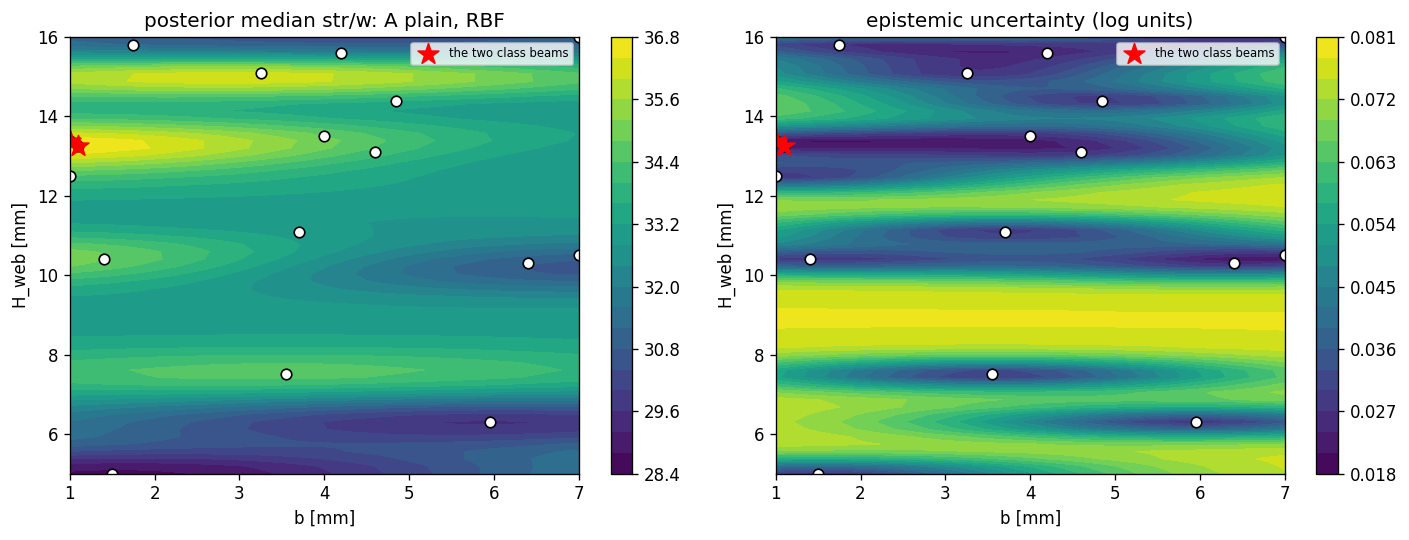

In [4]:
CHOICE    = "A plain"   # <<< your lane:   "A plain" | "B strength" | "C features" | "D residual"
KERNEL    = "RBF"       # <<< your smoothness assumption: "RBF" | "Matern"
NOISE_PCT = 3           # <<< your assumed repeatability, percent

gpF, fmuF, fsdF, ymF, cfgF = fit_lane(df, CHOICE, alpha=(NOISE_PCT/100)**2,
                                      kernel=KERNEL)
bg = np.linspace(1.0, 7.0, 63); Hg = np.linspace(5.0, 16.0, 60)
BB, HH = np.meshgrid(bg, Hg)
SWg, SDg = predict_sw(gpF, fmuF, fsdF, ymF, BB.ravel(), HH.ravel(),
                      cfgF["target"], cfgF["feats"])
MU, STD = SWg.reshape(BB.shape), SDg.reshape(BB.shape)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
for a, Z, t in [(ax[0], MU, f"posterior median str/w: {CHOICE}, {KERNEL}"),
                (ax[1], STD, "epistemic uncertainty (log units)")]:
    cf = a.contourf(BB, HH, Z, levels=20); fig.colorbar(cf, ax=a)
    a.scatter(df.b, df.H, c="w", edgecolor="k", s=40)
    a.scatter(df.b.iloc[-2:], df.H.iloc[-2:], c="red", marker="*", s=170,
              label="the two class beams")
    a.set_xlabel("b [mm]"); a.set_ylabel("H_web [mm]"); a.set_title(t); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

### The decision map: four panels, one argument

Before choosing, put the module's two models side by side on the same axes.
The four panels below are the figure most worth reading in this notebook —
they turn "which model do we trust *here*" into something you can point at:

1. **Calibrated physics** — predicted str/w with the governing-mode boundaries
   drawn on. Where the boundaries run is where the physics rests on its most
   fragile assumptions.
2. **Your GP posterior median** — what the data support, under your knobs.
3. **Physics minus GP** — the disagreement map. Near-zero where the two
   stories agree; large where at least one of them is wrong.
4. **Epistemic sigma** — where the GP is guessing.

Read your candidate against all four: Do the models agree there? Is the
agreement backed by nearby tests, or is it two extrapolations shaking hands?
Does the disagreement track a mode boundary? Is the attractive region
promising, or merely unexplored? These are card rows 6 and 7, drawn
instead of written.

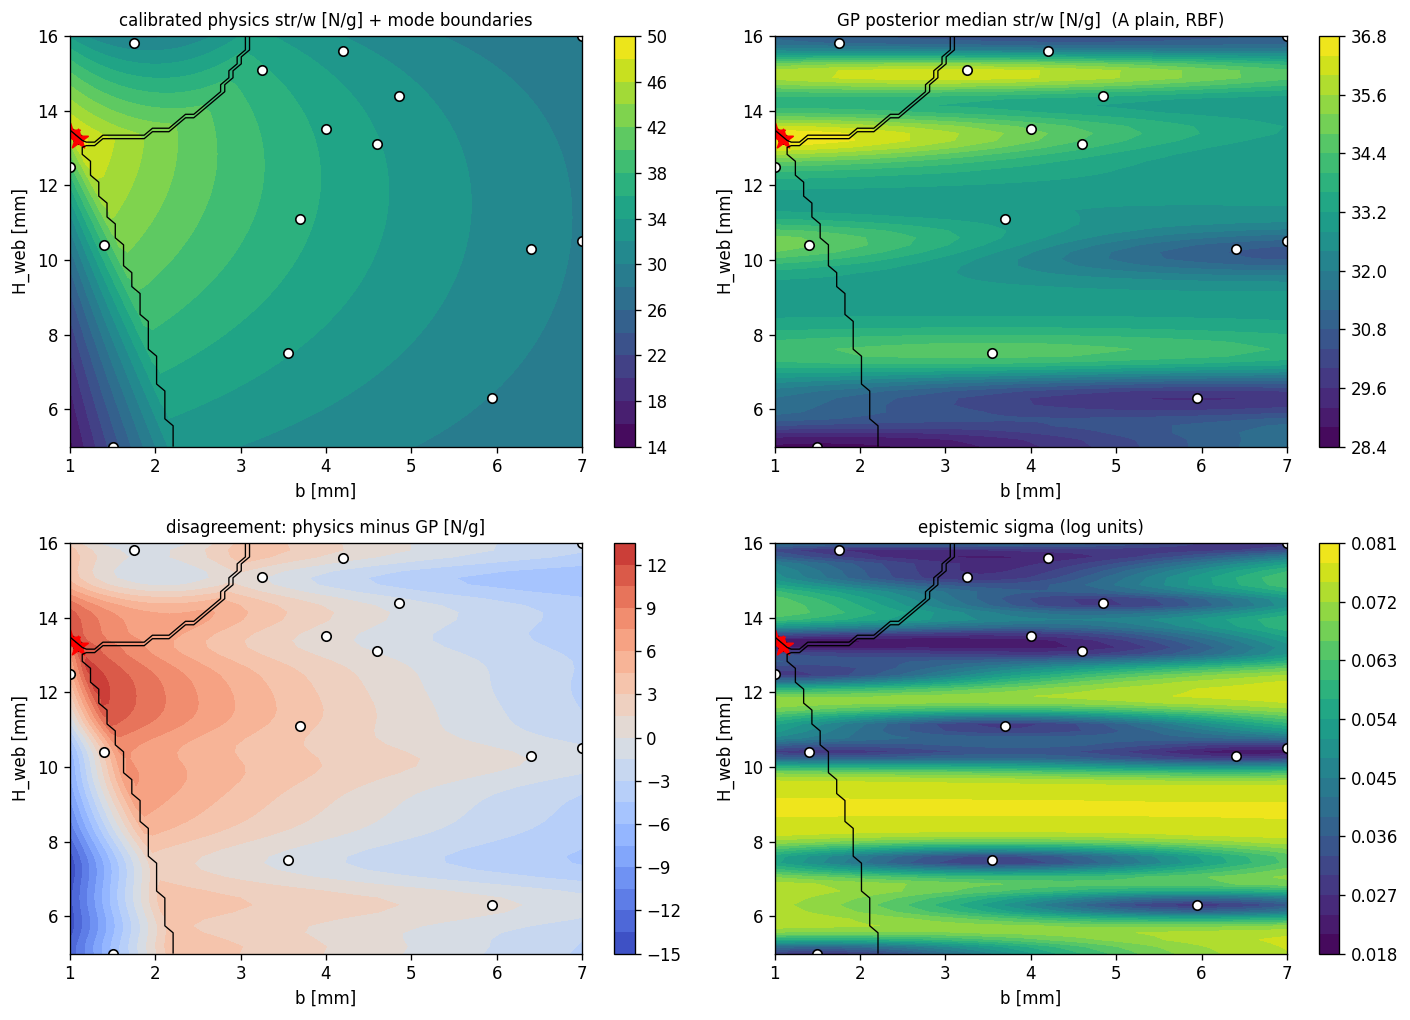

thin black lines on every panel: where the calibrated physics changes governing mode


In [5]:
PHYS = np.array([capacity(b, H, SY_CAL, K_CAL, TAU_CAL) /
                 estimated_mass_g(b, H)
                 for b, H in zip(BB.ravel(), HH.ravel())]).reshape(BB.shape)
MODE = np.array([{"bend": 0, "separation": 1, "LTB": 2}[
                 gov_mode(b, H, SY_CAL, K_CAL, TAU_CAL)]
                 for b, H in zip(BB.ravel(), HH.ravel())]).reshape(BB.shape)

fig, ax = plt.subplots(2, 2, figsize=(12, 8.6))
panels = [(ax[0, 0], PHYS, "calibrated physics str/w [N/g] + mode boundaries", "viridis"),
          (ax[0, 1], MU, f"GP posterior median str/w [N/g]  ({CHOICE}, {KERNEL})", "viridis"),
          (ax[1, 0], PHYS - MU, "disagreement: physics minus GP [N/g]", "coolwarm"),
          (ax[1, 1], STD, "epistemic sigma (log units)", "viridis")]
vmax = float(np.abs(PHYS - MU).max())
for a, Z, t, cm in panels:
    kw = dict(levels=20, cmap=cm)
    if cm == "coolwarm": kw.update(vmin=-vmax, vmax=vmax)
    cf = a.contourf(BB, HH, Z, **kw); fig.colorbar(cf, ax=a)
    a.contour(BB, HH, MODE, levels=[0.5, 1.5], colors="k", linewidths=0.8)
    a.scatter(df.b, df.H, c="w", edgecolor="k", s=32)
    a.scatter(df.b.iloc[-2:], df.H.iloc[-2:], c="red", marker="*", s=150)
    a.set_xlabel("b [mm]"); a.set_ylabel("H_web [mm]"); a.set_title(t, fontsize=10)
plt.tight_layout(); plt.show()
print("thin black lines on every panel: where the calibrated physics changes governing mode")


## 4. Choose your beam *(you write this — graded on the memo, not a checkpoint)*

The maps give you two numbers at every candidate design: `MU`, the predicted
str/w, and `STD`, how unsure the model is there (log units). An *acquisition
rule* collapses the two maps into one pick. Two rules are wired in:

- **`ACQ = "MUI"` — maximum upper interval, as in Pre-lab 2.**
  `score = log(MU) + psi*STD`: judge every design by its optimistic upper
  bound. `psi` is the explore–exploit dial, and it is yours to set.
  `psi = 0` ignores uncertainty and picks the best posterior median — pure
  exploitation. `psi = 1` credits each design one sigma of upside. Large
  `psi` chases the unexplored corners of the map. There is no correct value:
  ψ says how much your group values a *chance* at a better beam over a safe,
  good one. A well-reasoned ψ sounds like: "ψ = 0.5 — we get
  one print, the best beam tested so far already gives 37.48 N/g, and a
  gamble that fails leaves us nothing to show for it, so we mostly stick with
  what the model predicts well and give unexplored designs only a small
  benefit of the doubt." A weak one sounds like: "ψ = 1, because that is the
  default." Any value can earn full credit; only the second kind of reasoning
  cannot.
- **`ACQ = "EI"` — expected improvement.** Averages the improvement over the
  incumbent best tested beam (37.48 N/g) under the model's own uncertainty.
  No dial: it trades explore against exploit automatically, and it goes to
  zero wherever the model is confident nothing beats the incumbent.

How to discern: pick MUI when you want the risk dial in your own hands and
are prepared to defend a ψ in the memo; pick EI when you would rather let the
model's probabilities make the trade — and defend *that* delegation instead.
With the default lane, kernel, and noise, the two rules split: MUI ψ = 1
exploits the thin-web ridge, while EI — measuring improvement over a 37.48
incumbent it doubts it can beat nearby — gambles on the untested high-web
corner near (1.00, 14.9). The disagreement is itself evidence: it tells you
the model sees no cheap wins left, and your memo should say which side of
that bet your group takes and why.

Whatever the rule says, you hold a veto. The calibrated physics (`capacity`)
and the failure-note table are also in front of you — the standard move is to
strike regions the notes make you distrust (which beams peeled apart, and
where?).

One pattern earns that scrutiny before any other: a recommendation sitting
on an edge of the design box, and doubly so in a corner, where two edges
stack. An interior optimum is a claim the data can bracket from all sides; a
boundary optimum means the acquisition surface was still rising when it ran
out of box, so the model is really pointing at territory *outside* the box,
where it has no data at all. Edges are where your evidence is one-sided and
extrapolation is cheapest. They are also where physical extremes concentrate
— H_web = 16 is the lightest section at any b, so a model that overestimates
strength there gets an unearned strength-to-weight boost from the mass
division — and where the unmodeled mechanisms tend to live: the separation
notes cluster along thin b, and the tall-web corner is the LTB territory
where beam 9 twisted off its stand. An edge pick is not automatically wrong
— beam 16, the best beam tested, sits 0.10 mm from the b = 1.0 wall — but it
is automatically a bigger claim. Carrying it takes one of three things in
the memo: tested beams nearby, a physics story that survives the four-panel
map, or a plain statement that the print is buying information rather than
performance.

For orientation only: the *default* recipe — lane A, RBF, 3% noise, MUI
ψ = 1 — lands at **(b ≈ 1.39, H_web ≈ 14.88)**. You are free to submit
that; you are also free to beat it. Before adopting it, compare its coordinates
with the two class-query beams and with the thin-web examples where beams 12,
14, and 15 peeled apart at the flange-web interface. The MUI default is now an
interior point, but it remains in the thin, tall neighborhood; the default EI
comparison returns to the b = 1.0 wall, where the edge caution above applies.

**If your pick lands within |Δb| < 0.15 mm and |ΔH_web| < 0.30 mm of a
tested beam, the memo must say what a near-replicate print buys you.**
Under a 3–4% test scatter, verifying a suspiciously good result is a
legitimate answer; sleepwalking into a repeat is not.

In [6]:
from scipy.stats import norm

ACQ = "MUI"          # <<< your rule: "MUI" | "EI"
psi = 0.5            # <<< our dial: one print, incumbent 37.48 N/g already on the board;
                     #     mostly exploit, half a sigma of benefit of the doubt to untested designs

if ACQ == "MUI":
    score = np.log(MU) + psi*STD              # optimistic upper bound, log space
elif ACQ == "EI":
    best = np.log(df.str_to_weight.max())     # incumbent: best tested str/w
    z = (np.log(MU) - best) / STD
    score = STD * (z*norm.cdf(z) + norm.pdf(z))
else:
    raise ValueError(f"unknown ACQ {ACQ!r}: use 'MUI' or 'EI'")

i = np.unravel_index(np.argmax(score), score.shape)
b_final, H_final = float(BB[i]), float(HH[i])
print(f"FINAL DESIGN ({ACQ}):  b = {b_final:.2f} mm,  H_web = {H_final:.2f} mm")
print(f"  posterior median {MU[i]:.1f} N/g,  epistemic sigma_log {STD[i]:.3f},  "
      f"calibrated physics {capacity(b_final, H_final, SY_CAL, K_CAL, TAU_CAL)/estimated_mass_g(b_final, H_final):.1f} N/g")
print(f"  physics mode there: {gov_mode(b_final, H_final, SY_CAL, K_CAL, TAU_CAL)}")

FINAL DESIGN (MUI):  b = 1.00 mm,  H_web = 13.20 mm
  posterior median 36.8 N/g,  epistemic sigma_log 0.024,  calibrated physics 44.9 N/g
  physics mode there: separation


### 4b. The veto, applied

The unconstrained MUI psi = 0.5 argmax lands at (1.00, 13.20): the b = 1.0 wall, 0.19 mm from the tested class GP beam. We exercise the veto the section above describes and strike two regions before re-picking:

- b < 1.29: the wall plus the flange-web separation family (beams 12, 14, 15 all peeled in this b range, beam 15 at both interfaces), and both class queries already probed b = 1.0 to 1.1; a third print there is close to a replicate.
- H_web > 14.5: beam 9's tip/twist territory, where the light section inflates str/w through the mass denominator and the only nearby number is a fixture artifact.

The constrained pick is reported below, and the committed design is stated with it.


In [7]:
VETO = (BB >= 1.29) & (HH <= 14.5)
score_v = np.where(VETO, score, -np.inf)
iv = np.unravel_index(np.argmax(score_v), score_v.shape)
print(f"constrained argmax: b = {BB[iv]:.2f}, H_web = {HH[iv]:.2f}, "
      f"median {MU[iv]:.2f} N/g, sigma {STD[iv]:.3f}")

# Committed design: one grid notch interior of the veto boundary in b.
# The constrained argmax sits ON the b = 1.29 veto line (the score is still
# rising toward thin b), and the predicted cost of one more notch of web is
# 0.05 N/g. We take that notch: more separation margin, easier print.
b_final, H_final = 1.39, 13.20
iF = (np.abs(Hg - H_final).argmin(), np.abs(bg - b_final).argmin())
b_final, H_final = float(BB[iF]), float(HH[iF])
m_final = estimated_mass_g(b_final, H_final)
p_final = section_props(b_final, H_final)
r = NOISE_PCT/100
s_tot = np.sqrt(STD[iF]**2 + r**2)
lo, hi = MU[iF]*np.exp(-2*s_tot), MU[iF]*np.exp(2*s_tot)
print(f"\nCOMMITTED DESIGN: b = {b_final:.2f} mm, H_web = {H_final:.2f} mm, est mass {m_final:.2f} g")
print(f"  GP posterior median {MU[iF]:.2f} N/g  ({MU[iF]*m_final:.0f} N)")
print(f"  sigma_epi {STD[iF]:.4f}, sigma_total {s_tot:.4f} (log)")
print(f"  z=2 interval, one future test: [{lo:.1f}, {hi:.1f}] N/g = [{lo*m_final:.0f}, {hi*m_final:.0f}] N")
print(f"  calibrated physics: P_bend={P_bend(p_final,SY_CAL):.0f}, "
      f"P_sep={P_sep(p_final,TAU_CAL):.0f}, P_LTB={P_LTB(p_final,SY_CAL,K_CAL):.0f} N, "
      f"mode={gov_mode(b_final,H_final,SY_CAL,K_CAL,TAU_CAL)}")
print(f"  physics str/w: {capacity(b_final,H_final,SY_CAL,K_CAL,TAU_CAL)/m_final:.1f} N/g")


constrained argmax: b = 1.29, H_web = 13.20, median 36.68 N/g, sigma 0.023

COMMITTED DESIGN: b = 1.39 mm, H_web = 13.20 mm, est mass 13.55 g
  GP posterior median 36.65 N/g  (497 N)
  sigma_epi 0.0231, sigma_total 0.0379 (log)
  z=2 interval, one future test: [34.0, 39.5] N/g = [461, 536] N
  calibrated physics: P_bend=635, P_sep=797, P_LTB=635 N, mode=bend
  physics str/w: 46.8 N/g


### Optional: sweep every knob combination

Memo prompt 5 checks a handful of settings by hand. For a stronger case,
write your own code, from scratch, that loops over the combinations: four
lanes, two kernels, several noise values, both acquisition rules, and two or
three dial values. Collect each run's final coordinates into one table, save
it as a CSV, and plot where the picks land on the design box.

Read the result two ways. A region where many combinations agree is stable:
a design there does not hang on any single assumption. A knob that moves the
pick far is an assumption doing real work, and card row 4 asks you to name
it. If your recommendation holds only under your exact settings, say so in
the memo, then either move to the stable region or defend the sensitivity.

The sweep is optional, and no template is provided on purpose: the loop is
yours to design. What it produces is direct evidence for memo prompt 5 and
card row 4.

### Knob sweep (section 13, done)

Every combination of lane, kernel, noise in {1, 3, 4.4, 10}%, and acquisition rule, 160 runs, saved to `knob_sweep.csv`.

top pick locations across 160 knob combinations:
b     H    
1.39  11.71    29
1.00  16.00    25
1.10  13.20    10
1.00  13.20     8
      13.39     8
2.26  13.76     7
1.00  14.88     6
      13.76     5


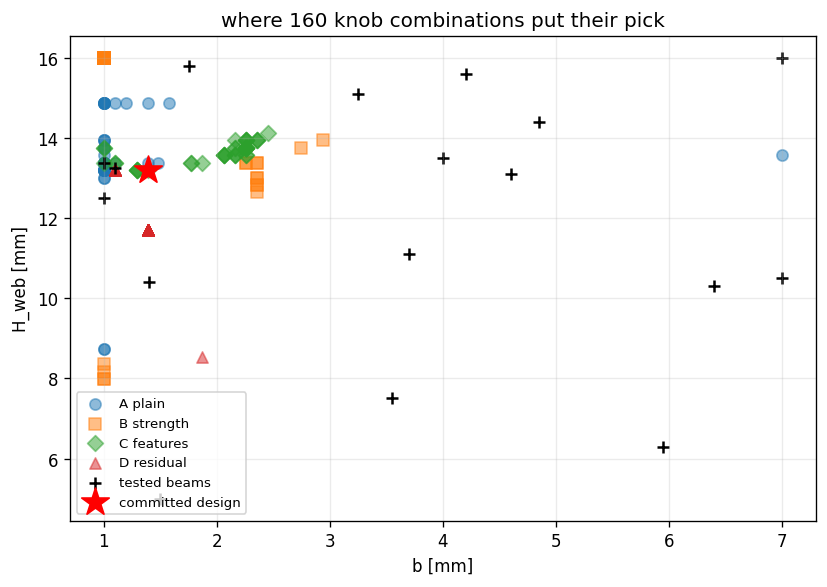

In [8]:
# Full knob sweep: 4 lanes x 2 kernels x 4 noise values x 5 acquisition settings = 160 runs
sweep_rows = []
for lane in LANES:
    for kern in ("RBF", "Matern"):
        for npct in (1, 3, 4.4, 10):
            gS, fmS, fsS, ymS, cfS = fit_lane(df, lane, alpha=(npct/100)**2, kernel=kern)
            SWs, SDs = predict_sw(gS, fmS, fsS, ymS, BB.ravel(), HH.ravel(),
                                  cfS["target"], cfS["feats"])
            MUs, STDs = SWs.reshape(BB.shape), SDs.reshape(BB.shape)
            for acq_name, dial in [("MUI",0.0),("MUI",0.5),("MUI",1.0),("MUI",2.0),("EI",0.0)]:
                if acq_name == "MUI":
                    sc = np.log(MUs) + dial*STDs
                else:
                    bst = np.log(df.str_to_weight.max())
                    zz = (np.log(MUs) - bst)/STDs
                    sc = STDs*(zz*norm.cdf(zz) + norm.pdf(zz))
                j = np.unravel_index(np.argmax(sc), sc.shape)
                sweep_rows.append(dict(lane=lane, kernel=kern, noise=npct,
                                       acq=acq_name, dial=dial,
                                       b=float(BB[j]), H=float(HH[j]),
                                       mu=float(MUs[j]), sd=float(STDs[j])))
sweep = pd.DataFrame(sweep_rows)
sweep.to_csv("knob_sweep.csv", index=False)
print("top pick locations across 160 knob combinations:")
print(sweep.groupby([sweep.b.round(2), sweep.H.round(2)]).size()
      .sort_values(ascending=False).head(8).to_string())

fig, ax = plt.subplots(figsize=(7, 5))
for lane, mk in zip(LANES, "osD^"):
    sub = sweep[sweep.lane == lane]
    ax.scatter(sub.b, sub.H, marker=mk, alpha=0.5, label=lane, s=45)
ax.scatter(df.b, df.H, c="k", marker="+", s=50, label="tested beams")
ax.scatter([1.39], [13.20], c="red", marker="*", s=300, label="committed design")
ax.set_xlabel("b [mm]"); ax.set_ylabel("H_web [mm]")
ax.set_title("where 160 knob combinations put their pick")
ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()


## Memo

**File the decision card first.** Fill rows 1–10 of
`ME323_Module1_DecisionCard.md` and its preregistration table, and submit them
with this notebook — the preregistration is due before your beam is printed,
and graders read the card before the memo. The prompts below map onto card
rows; the card is the skeleton, the memo is the argument.

Write the memo in markdown cells below this one, answering these six prompts
in order — about half a page for 1–4, a few sentences each for 5–6. It covers
only these prompts; the pre-lab questions stay in their own notebooks.

1. The two class beams: use the generated scoreboard percentages, with their
   stated denominators. What does each miss reveal, and which miss is costlier
   for the intended design decision?
2. Your lane: what did the LOO table say under both kernels, and did you
   follow it? If you chose C or D, what does physics contribute between the
   observations? (Card rows 3 and 4.)
3. Risk: name your acquisition rule (`ACQ`, plus its dial) and your
   `NOISE_PCT`, and use the printed posterior median, epistemic sigma, and
   final coordinates to explain whether you exploited, explored, or
   replicated. Is the main risk a weak beam or a model that is confidently
   wrong? (Card row 8.)
4. Limits: compare your coordinates with the thin-web flange-web-separation
   notes and with the four-panel decision map. Where could that unmodeled
   mechanism affect your design? (Card rows 6–7, 10.)
5. Stress test: rerun sections 3 and 4 with the other kernel and at 1% and 10% noise. Did
   your coordinates survive? State either the stable-neighborhood conclusion
   or the case for buying information instead. (Card row 4.)
6. Name the **three figures** (by section) that carry your argument, one
   sentence each on the work it does. Graders may ignore every other plot.

The default-parameter design is already computed by the section-4 code. You do
not need a new optimization cell unless you choose a different decision rule.

## Memo (Group answer)

### 1. The two class beams
The equation beam was predicted at 48.7 N/g and returned 37.48 (23.0% below prediction, on the estimated-mass basis); the locked GP beam was predicted at 36.7 and returned 36.65 (0.0% miss). The equation miss reveals a systematic optimism at the optimum: the calibration fit 15 beams at 5.3% MAPE, but the optimizer then drove to the exact point where all three capacity surfaces tie, which is where every calibrated parameter's error compounds. Maximizing a fitted surface selects for its most optimistic error (a winner's curse), and 23% is the measured size of it here. The GP miss reveals honest interpolation next to data, and also that honesty alone found nothing new. For the design decision, the physics miss is costlier in kind: decisions are made at the model's most optimistic point, which is exactly where its bias concentrates, so an uncorrected physics optimizer will be reliably over-sold precisely where it is used. The right response is not to discard the physics but to let the measured 23% correction discipline every physics-flavored prediction in the thin-b ridge, which is what our lane choice below does.

### 2. Lane (card rows 3 and 4)
LOO RMSE: D residual 2.38/2.34 N/g (RBF/Matern), A plain 2.94/2.89, C features 3.07/3.13, B strength 6.35/5.40. We chose lane A over the LOO winner D, deliberately. D's LOO edge is earned mostly on interior bend beams where its physics is anchored; where we are designing, D's behavior depends on extrapolating the learned correction factor across H with a fitted length scale of about 0.5 mm. The measured corrections are strongly structured there: beams 16 and 17 came in at 0.77 and 0.79 of calibrated physics, beam 15 at 0.88, beam 14 at 0.93. D's favorite design, (1.39, 11.71), gets a correction of 0.94 only because the harsh corrections at H near 13.3 cannot reach it through the short H length scale, and lane A disagrees with D by 25% at that exact point (33.0 vs 42.5 N/g). We read that as an extrapolation artifact wearing the LOO winner's credibility. Near our committed design all three credible lanes agree within 1 N/g (A 36.65, D 37.40, C 37.58), so the lane choice costs nothing there, and A is the model whose failure mode we can see coming: its sigma balloons where it is guessing.

### 3. Risk posture (card row 8)
MUI with psi = 0.5, NOISE_PCT = 3, plus an explicit veto (b >= 1.29, H_web <= 14.5) stated in section 4b. This is exploitation: one print, the incumbent is 37.48 N/g, and a failed gamble leaves the group nothing. Committed coordinates (1.39, 13.20): posterior median 36.65 N/g (497 N at 13.55 g), sigma_epi 0.023. The print is still informative, not a replicate: the tested ridge spans only b = 1.00 to 1.10, and our beam tests the GP's claim (fitted b length scale 3.4 mm) that the ridge is flat in b out to 1.4, with 40% more web. The main risk is not a weak beam (the z = 2 lower bound, 461 N, is still a good beam); it is a confidently wrong model, and we declined the version of that risk with the biggest exposure, D's 42.5 N/g promise.

### 4. Limits (card rows 6, 7, 10)
Our b = 1.39 sits inside the b range where every separation note lives: beams 12 (1.5, 5.0), 14 (1.4, 10.4), and 15 (1.0, 12.5) all peeled at the flange-web interface, and 15 also fractured 80% through its bottom interface. At our H the calibrated check gives 26% separation margin (797 vs 635 N), but tau_i drifts between print sessions and beam 15 shows the mechanism appearing where the single-plane check claims margin, so the margin is softer than it prints. On the four-panel map, our point sits essentially on the bend/LTB boundary (P_bend 635 vs P_LTB 635, a tie) and in the deep disagreement zone: physics says 46.8 N/g, the GP says 36.7. We side with the GP because the disagreement is measured, not hypothetical: two beams 0.29 and 0.43 mm away returned 37.5 and 36.6 N/g, 21 to 23% below calibrated physics. The physics knife-edge optimism is a known, locally quantified bias; the GP carries it and the equations do not.

### 5. Stress test (card row 4)
Under the veto, the constrained MUI psi = 0.5 pick is (1.29, 13.20) for lane A with RBF and Matern at 1% and 3% noise, and moves only one grid notch in H at 4.4% and 10% ((1.29, 13.95) and (1.29, 13.39)). Lane D, similarly constrained, joins the same point at 10% noise; lane C converges there at 10% as well. So the neighborhood b = 1.3 to 1.4, H = 13.2 to 14.0 is stable across every kernel and noise setting we tried, and the exact coordinate wobbles a notch. The full 160-run sweep tells the same story: the picks cluster in two attractors, the thin-b ridge at H 13.2 to 13.4 and D's (1.39, 11.71), and the second attractor exists only for lane D below 10% noise. Stable-neighborhood conclusion: every defensible model points at the ridge; we chose a printable interior point in it, one notch inside our own veto boundary for separation margin at a predicted cost of 0.05 N/g.

### 6. The three figures
Section 2's LOO table: establishes which lanes deserve trust and by how little, licensing the overrule argument in prompt 2. Section 3b's four-panel decision map: places the committed design on the mode boundary, shows the 10 N/g physics-GP disagreement there, and shows the two tested beams that adjudicate it. The section 13 sweep scatter: shows 160 knob combinations clustering on the ridge, which is the evidence that the neighborhood, not our particular settings, drives the recommendation.
